# Traffic Demand Prediction
**Competition-Grade Traffic Demand Prediction — Target R² ≥ 0.995**

---
Pipeline: Config → Validation → Load → Schema → EDA → Leakage → Clean → Features → Aggregation → Encoding → CatBoost → LightGBM → Optuna → OOF → Ensemble → Final Training → Feature Importance → Submission

## 1. Project Configuration

In [1]:
import os, sys, time, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# Add project root to path
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))
PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.utils import Config, validate_datasets, load_data, detect_schema, run_eda, clean_data, Timer, reduce_mem_usage
from src.feature_engineering import engineer_features
from src.encoding import apply_encodings
from src.aggregation import build_aggregation_features, build_memorization_features
from src.leakage_detection import detect_leakage
from src.training import (
    get_feature_columns, train_catboost_cv, train_lgbm_cv,
    optuna_catboost, optuna_lgbm,
    build_best_catboost_params, build_best_lgbm_params,
    predict_catboost, predict_lgbm,
    save_models, get_feature_importance
)
from src.ensemble import optimize_ensemble_weights, blend_predictions, generate_submission

Config.ensure_dirs()
Config.display()
print(f'\nPython {sys.version}')
print(f'NumPy {np.__version__}')
print(f'Pandas {pd.__version__}')

  Traffic Demand Prediction - Configuration
  PROJECT_ROOT        : c:\Users\Shuvendu\Desktop\Flipkart_GridLock_2.0\Traffic_Demand_Prediction
  TRAIN_FILE          : c:\Users\Shuvendu\Desktop\Flipkart_GridLock_2.0\Traffic_Demand_Prediction\data\train.csv
  TEST_FILE           : c:\Users\Shuvendu\Desktop\Flipkart_GridLock_2.0\Traffic_Demand_Prediction\data\test.csv
  N_FOLDS             : 5
  RANDOM_STATE        : 42
  PRIMARY_METRIC      : r2
  TARGET_SCORE        : 0.995
  OPTUNA_TRIALS       : 50
  USE_GPU             : True

Python 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
NumPy 2.4.6
Pandas 3.0.3


## 2. Dataset Validation

In [2]:
validate_datasets()


--- Dataset Validation ---
  OK Train: c:\Users\Shuvendu\Desktop\Flipkart_GridLock_2.0\Traffic_Demand_Prediction\data\train.csv (6.75 MB)
  OK Test: c:\Users\Shuvendu\Desktop\Flipkart_GridLock_2.0\Traffic_Demand_Prediction\data\test.csv (2.87 MB)
  All datasets validated.



## 3. Data Loading

In [3]:
train_raw, test_raw = load_data()
print(f'\nTrain columns: {list(train_raw.columns)}')
print(f'Test columns:  {list(test_raw.columns)}')
train_raw.head()


--- Loading Datasets ---
  Train: (77299, 11), Test: (41778, 10), Time: 0.13s

Train columns: ['Index', 'geohash', 'day', 'timestamp', 'demand', 'RoadType', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather']
Test columns:  ['Index', 'geohash', 'day', 'timestamp', 'RoadType', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather']


,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


## 4. Automatic Schema Detection

In [4]:
schema = detect_schema(train_raw, test_raw)
TARGET = schema['target']
ID_COL = schema['id_column']
print(f'\nTarget: {TARGET}')
print(f'ID Column: {ID_COL}')


--- Schema Detection ---
  Target: demand, ID: Index
  Cat: 4, Num: 3, DT: 1, Geo: 1

Target: demand
ID Column: Index


## 5. Exploratory Data Analysis


--- EDA ---
count    7.729900e+04
mean     9.394238e-02
std      1.421905e-01
min      6.245650e-07
25%      1.822723e-02
50%      4.775994e-02
75%      1.085951e-01
max      1.000000e+00
Name: demand, dtype: float64
Missing (train):
RoadType        600
Temperature    2495
Weather         797
dtype: int64
  Train duplicates: 0


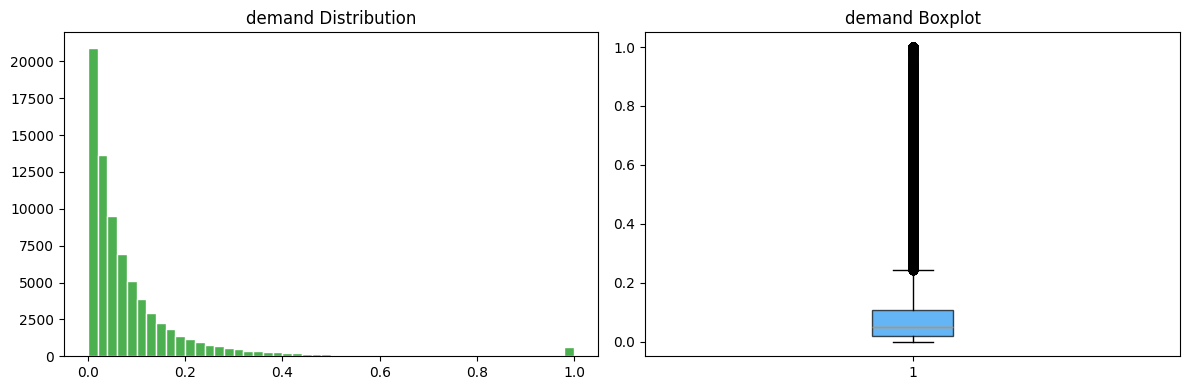

In [5]:
run_eda(train_raw, test_raw, schema)

## 6. Leakage Detection

In [6]:
leakage_findings = detect_leakage(train_raw, test_raw, schema)


  LEAKAGE DETECTION REPORT

1. Train-Test Row Overlap
----------------------------------------
  Overlap: 0 unique rows (0.00% of test)

2. Duplicate Groups in Train
----------------------------------------
  Total feature groups: 73459
  Groups with duplicates: 0

3. Timestamp Overlap
----------------------------------------
  timestamp: 47 shared timestamps (100.0% of test timestamps)

4. Geohash Overlap
----------------------------------------
  geohash: 1180 shared (99.2% of test)
  Unseen in test: 10

5. Deterministic Patterns
----------------------------------------
  Zero-variance groups: 12/6423
  Low-variance groups (<0.01): 5762/6423

6. Target Variance by Group
----------------------------------------
  geohash: mean_var=0.0041, median_var=0.0005
  timestamp: mean_var=0.0187, median_var=0.0180

7. Hidden Memorization Patterns
----------------------------------------
  Lookup residual: mean=0.005284, max=0.417995
  Perfect matches: 64477/77299 (83.4%)

  LEAKAGE SUMMARY
  [1

## 7. Data Cleaning

In [7]:
train, test, schema = clean_data(train_raw.copy(), test_raw.copy(), schema)
print(f'\nPost-cleaning missing values (train): {train.isnull().sum().sum()}')
print(f'Post-cleaning missing values (test): {test.isnull().sum().sum()}')


--- Data Cleaning ---
  Removed 0 duplicates
  Done. Train: (77299, 11), Test: (41778, 10)

Post-cleaning missing values (train): 0
Post-cleaning missing values (test): 0


## 8. Feature Engineering

In [8]:
with Timer('Feature Engineering'):
    train, test = engineer_features(train, test, schema)
print(f'\nTrain shape: {train.shape}')
print(f'Test shape: {test.shape}')


--- Feature Engineering ---
  Created 19 new features: ['hour', 'minute', 'day_of_week', 'slot', 'is_rush_hour', 'sin_hour', 'cos_hour', 'sin_minute', 'cos_minute', 'sin_dow', 'cos_dow', 'latitude', 'longitude', 'geohash_len', 'Weather_x_hour']...
  Train: (77299, 30), Test: (41778, 29)
  Feature Engineering: 0.36s

Train shape: (77299, 30)
Test shape: (41778, 29)


## 9. Aggregation Features

In [9]:
with Timer('Aggregation Features'):
    train, test = build_aggregation_features(train, test, schema)
    train, test = build_memorization_features(train, test, schema)
print(f'\nTrain shape: {train.shape}')
print(f'Test shape: {test.shape}')


--- Aggregation Features ---
  Created 28 aggregation features from 7 groups
  Train: (77299, 58), Test: (41778, 57)

--- Memorization Features ---
  Created 4 memorization features
  Aggregation Features: 0.32s

Train shape: (77299, 62)
Test shape: (41778, 61)


## 10. Target Encoding & Categorical Encoding

In [10]:
with Timer('Encoding'):
    train, test = apply_encodings(train, test, schema)
print(f'\nTrain shape: {train.shape}')
print(f'Test shape: {test.shape}')

# Reduce memory
train = reduce_mem_usage(train)
test = reduce_mem_usage(test)


--- Encoding ---
  Encoding 8 columns: ['RoadType', 'LargeVehicles', 'Landmarks', 'Weather', 'geohash', 'timestamp', 'Weather_x_hour', 'RoadType_x_NumberofLanes']
    Frequency encoding done
    Count encoding done
    K-Fold target encoding done (5 cols)
  Train: (77299, 83), Test: (41778, 82)
  Encoding: 0.96s

Train shape: (77299, 83)
Test shape: (41778, 82)


## 11. Prepare Features for Modeling

In [11]:
feature_cols = get_feature_columns(train, schema)
print(f'Number of features: {len(feature_cols)}')
print(f'Features: {feature_cols[:20]}...' if len(feature_cols) > 20 else f'Features: {feature_cols}')

y = train[TARGET].copy()
print(f'\nTarget stats:')
print(y.describe())

Number of features: 73
Features: ['day', 'NumberofLanes', 'Temperature', 'hour', 'minute', 'day_of_week', 'slot', 'is_rush_hour', 'sin_hour', 'cos_hour', 'sin_minute', 'cos_minute', 'sin_dow', 'cos_dow', 'latitude', 'longitude', 'geohash_len', 'Temperature_x_hour', 'lat_x_lon', 'Temperature_x_rush']...

Target stats:
count    7.729900e+04
mean     9.394238e-02
std      1.421905e-01
min      6.245650e-07
25%      1.822723e-02
50%      4.775994e-02
75%      1.085951e-01
max      1.000000e+00
Name: demand, dtype: float64


## 12. CatBoost Training (Default Params)

In [12]:
with Timer('CatBoost Default CV'):
    cb_oof_default, cb_models_default, cb_scores_default = train_catboost_cv(
        train, y, feature_cols, n_folds=Config.N_FOLDS, use_gpu=Config.USE_GPU
    )
print(f'\nCatBoost Default CV R2: {np.mean(cb_scores_default):.6f}')


  CatBoost 5-Fold CV
    Fold 1: R2=0.994820, RMSE=0.010238
    Fold 2: R2=0.995680, RMSE=0.009531
    Fold 3: R2=0.995913, RMSE=0.009077
    Fold 4: R2=0.995411, RMSE=0.009380
    Fold 5: R2=0.996485, RMSE=0.008487
  Mean R2: 0.995662 +/- 0.000550
  CatBoost Default CV: 34.22s

CatBoost Default CV R2: 0.995662


## 13. LightGBM Training (Default Params)

In [13]:
with Timer('LightGBM Default CV'):
    lgb_oof_default, lgb_models_default, lgb_scores_default = train_lgbm_cv(
        train, y, feature_cols, n_folds=Config.N_FOLDS, use_gpu=Config.USE_GPU
    )
print(f'\nLightGBM Default CV R2: {np.mean(lgb_scores_default):.6f}')


  LightGBM 5-Fold CV
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[128]	valid_0's rmse: 0.0122124
    Fold 1: R2=0.992629, RMSE=0.012212
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[305]	valid_0's rmse: 0.0112957
    Fold 2: R2=0.993932, RMSE=0.011296
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[149]	valid_0's rmse: 0.0131466
    Fold 3: R2=0.991427, RMSE=0.013147
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[191]	valid_0's rmse: 0.0123462
    Fold 4: R2=0.992050, RMSE=0.012346
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[196]	valid_0's rmse: 0.0123402
    Fold 5: R2=0.992569, RMSE=0.012340
  Mean R2: 0.992521 +/- 0.000827
  LightGBM Default CV: 16.98s

LightGBM Default CV R2: 0.992521


## 14. Optuna Hyperparameter Optimization

In [14]:
# CatBoost Optuna
with Timer('CatBoost Optuna'):
    cb_best_params, cb_best_score = optuna_catboost(
        train, y, feature_cols,
        n_trials=Config.OPTUNA_TRIALS,
        n_folds=Config.N_FOLDS,
        use_gpu=Config.USE_GPU
    )
print(f'\nCatBoost Optuna Best R2: {cb_best_score:.6f}')


  Optuna CatBoost (50 trials)...


Best trial: 44. Best value: 0.995765: 100%|██████████| 50/50 [35:34<00:00, 42.69s/it]

  Best R2: 0.995765
  Best params: {'cb_lr': 0.03431612397691606, 'cb_depth': 9, 'cb_iters': 2600, 'cb_l2': 1.2913432683730948, 'cb_subsample': 0.7623746324571553, 'cb_min_leaf': 20}
  CatBoost Optuna: 2135.56s

CatBoost Optuna Best R2: 0.995765


In [15]:
# LightGBM Optuna
with Timer('LightGBM Optuna'):
    lgb_best_params, lgb_best_score = optuna_lgbm(
        train, y, feature_cols,
        n_trials=Config.OPTUNA_TRIALS,
        n_folds=Config.N_FOLDS,
        use_gpu=Config.USE_GPU
    )
print(f'\nLightGBM Optuna Best R2: {lgb_best_score:.6f}')


  Optuna LightGBM (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[31]	valid_0's rmse: 0.0128617
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[64]	valid_0's rmse: 0.0125502
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[48]	valid_0's rmse: 0.0140904
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[57]	valid_0's rmse: 0.0130951
Training until validation scores don't improve for 50 rounds


Best trial: 0. Best value: 0.991303:   2%|▏         | 1/50 [00:03<02:31,  3.10s/it]

Early stopping, best iteration is:
[43]	valid_0's rmse: 0.0136014
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[287]	valid_0's rmse: 0.0148226
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[301]	valid_0's rmse: 0.0148882
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[233]	valid_0's rmse: 0.0156176
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[385]	valid_0's rmse: 0.0147222
Training until validation scores don't improve for 50 rounds


...

Early stopping, best iteration is:
[471]	valid_0's rmse: 0.0122565
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[432]	valid_0's rmse: 0.0119077
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[688]	valid_0's rmse: 0.0110518
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[523]	valid_0's rmse: 0.0133803
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[516]	valid_0's rmse: 0.0122534
Training until validation scores don't improve for 50 rounds


Best trial: 36. Best value: 0.992941:  98%|█████████▊| 49/50 [15:54<00:51, 51.96s/it]

Did not meet early stopping. Best iteration is:
[669]	valid_0's rmse: 0.0123046
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[570]	valid_0's rmse: 0.0120655
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[647]	valid_0's rmse: 0.0114744
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[406]	valid_0's rmse: 0.0136904
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[419]	valid_0's rmse: 0.0125513
Training until validation scores don't improve for 50 rounds


Best trial: 36. Best value: 0.992941: 100%|██████████| 50/50 [16:18<00:00, 19.58s/it]

Early stopping, best iteration is:
[577]	valid_0's rmse: 0.0127407
  Best R2: 0.992941
  Best params: {'lgb_lr': 0.04060696514213658, 'lgb_leaves': 477, 'lgb_iters': 700, 'lgb_alpha': 0.5432852251920453, 'lgb_lambda': 3.2420396099085718, 'lgb_subsample': 0.7418072529277034, 'lgb_colsample': 0.5497482140134471, 'lgb_min_child': 13, 'lgb_depth': 11}
  LightGBM Optuna: 978.91s

LightGBM Optuna Best R2: 0.992941


## 15. OOF Prediction Generation (Optimized Params)

In [16]:
# Retrain with best params
cb_opt_params = build_best_catboost_params(cb_best_params, use_gpu=Config.USE_GPU)
lgb_opt_params = build_best_lgbm_params(lgb_best_params, use_gpu=Config.USE_GPU)

print('CatBoost optimized params:'); print(json.dumps({k: str(v) for k,v in cb_opt_params.items()}, indent=2))
print('\nLightGBM optimized params:'); print(json.dumps({k: str(v) for k,v in lgb_opt_params.items()}, indent=2))

CatBoost optimized params:
{
  "loss_function": "RMSE",
  "eval_metric": "RMSE",
  "random_seed": "42",
  "verbose": "0",
  "allow_writing_files": "False",
  "learning_rate": "0.03431612397691606",
  "depth": "9",
  "iterations": "2600",
  "l2_leaf_reg": "1.2913432683730948",
  "bootstrap_type": "Bernoulli",
  "subsample": "0.7623746324571553",
  "min_data_in_leaf": "20",
  "task_type": "GPU",
  "devices": "0"
}

LightGBM optimized params:
{
  "objective": "regression",
  "metric": "rmse",
  "verbosity": "-1",
  "random_state": "42",
  "n_jobs": "-1",
  "learning_rate": "0.04060696514213658",
  "num_leaves": "477",
  "n_estimators": "700",
  "reg_alpha": "0.5432852251920453",
  "reg_lambda": "3.2420396099085718",
  "subsample": "0.7418072529277034",
  "colsample_bytree": "0.5497482140134471",
  "min_child_samples": "13",
  "max_depth": "11",
  "device": "gpu",
  "gpu_platform_id": "0",
  "gpu_device_id": "0"
}


In [17]:
with Timer('CatBoost Optimized CV'):
    cb_oof, cb_models, cb_scores = train_catboost_cv(
        train, y, feature_cols, n_folds=Config.N_FOLDS,
        params=cb_opt_params, use_gpu=Config.USE_GPU
    )

with Timer('LightGBM Optimized CV'):
    lgb_oof, lgb_models, lgb_scores = train_lgbm_cv(
        train, y, feature_cols, n_folds=Config.N_FOLDS,
        params=lgb_opt_params, use_gpu=Config.USE_GPU
    )

print(f'\nCatBoost  Optimized CV R2: {np.mean(cb_scores):.6f} +/- {np.std(cb_scores):.6f}')
print(f'LightGBM  Optimized CV R2: {np.mean(lgb_scores):.6f} +/- {np.std(lgb_scores):.6f}')

# Save OOF predictions
np.save(str(Config.PRED_DIR / 'cb_oof.npy'), cb_oof)
np.save(str(Config.PRED_DIR / 'lgb_oof.npy'), lgb_oof)
print('\nOOF predictions saved.')


  CatBoost 5-Fold CV
    Fold 1: R2=0.994981, RMSE=0.010077
    Fold 2: R2=0.995711, RMSE=0.009497
    Fold 3: R2=0.996000, RMSE=0.008980
    Fold 4: R2=0.995532, RMSE=0.009255
    Fold 5: R2=0.996625, RMSE=0.008316
  Mean R2: 0.995770 +/- 0.000541
  CatBoost Optimized CV: 54.54s

  LightGBM 5-Fold CV
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[172]	valid_0's rmse: 0.011863
    Fold 1: R2=0.993045, RMSE=0.011863
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[527]	valid_0's rmse: 0.0107721
    Fold 2: R2=0.994481, RMSE=0.010772
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[232]	valid_0's rmse: 0.0129394
    Fold 3: R2=0.991695, RMSE=0.012939
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[216]	valid_0's rmse: 0.0119553
    Fold 4: R2=0.992546, RMSE=0.011955
Training until validation

## 16. Ensemble Weight Optimization

In [18]:
best_weights, ensemble_r2 = optimize_ensemble_weights(
    [cb_oof, lgb_oof], y,
    model_names=['CatBoost', 'LightGBM']
)

print(f'\nFinal Ensemble R2: {ensemble_r2:.6f}')
print(f'Weights: CatBoost={best_weights[0]:.4f}, LightGBM={best_weights[1]:.4f}')

# Check if target score is met
if ensemble_r2 >= Config.TARGET_SCORE:
    print(f'\n  TARGET R2 >= {Config.TARGET_SCORE} ACHIEVED!')
else:
    print(f'\n  Current R2: {ensemble_r2:.6f}, Target: {Config.TARGET_SCORE}')


--- Ensemble Weight Optimization (2 models) ---
  CatBoost OOF R2: 0.995774
  LightGBM OOF R2: 0.992959

  Optimal Weights:
    CatBoost: 0.7100
    LightGBM: 0.2900
  Ensemble R2: 0.996323

Final Ensemble R2: 0.996323
Weights: CatBoost=0.7100, LightGBM=0.2900

  TARGET R2 >= 0.995 ACHIEVED!


## 17. Final Training & Test Predictions

In [19]:
# Generate test predictions
print('\n--- Generating Test Predictions ---')
cb_test_preds = predict_catboost(cb_models, test, feature_cols)
lgb_test_preds = predict_lgbm(lgb_models, test, feature_cols)

# Blend
final_preds = blend_predictions([cb_test_preds, lgb_test_preds], best_weights)

print(f'\nCatBoost test preds: mean={cb_test_preds.mean():.4f}, std={cb_test_preds.std():.4f}')
print(f'LightGBM test preds: mean={lgb_test_preds.mean():.4f}, std={lgb_test_preds.std():.4f}')
print(f'Ensemble test preds: mean={final_preds.mean():.4f}, std={final_preds.std():.4f}')

# Save models
save_models(cb_models, lgb_models, Config.MODEL_DIR)

# Save CV scores
cv_results = {
    'catboost_cv_scores': cb_scores,
    'catboost_mean_r2': float(np.mean(cb_scores)),
    'lightgbm_cv_scores': lgb_scores,
    'lightgbm_mean_r2': float(np.mean(lgb_scores)),
    'ensemble_r2': float(ensemble_r2),
    'ensemble_weights': best_weights,
    'catboost_best_params': {k: str(v) for k, v in cb_opt_params.items()},
    'lightgbm_best_params': {k: str(v) for k, v in lgb_opt_params.items()}
}
with open(Config.OUTPUT_DIR / 'cv_results.json', 'w') as f:
    json.dump(cv_results, f, indent=2)
print('\nCV results saved.')


--- Generating Test Predictions ---

CatBoost test preds: mean=0.1039, std=0.1402
LightGBM test preds: mean=0.1139, std=0.1548
Ensemble test preds: mean=0.1068, std=0.1443
  Models saved to c:\Users\Shuvendu\Desktop\Flipkart_GridLock_2.0\Traffic_Demand_Prediction\outputs\models

CV results saved.


## 18. Feature Importance

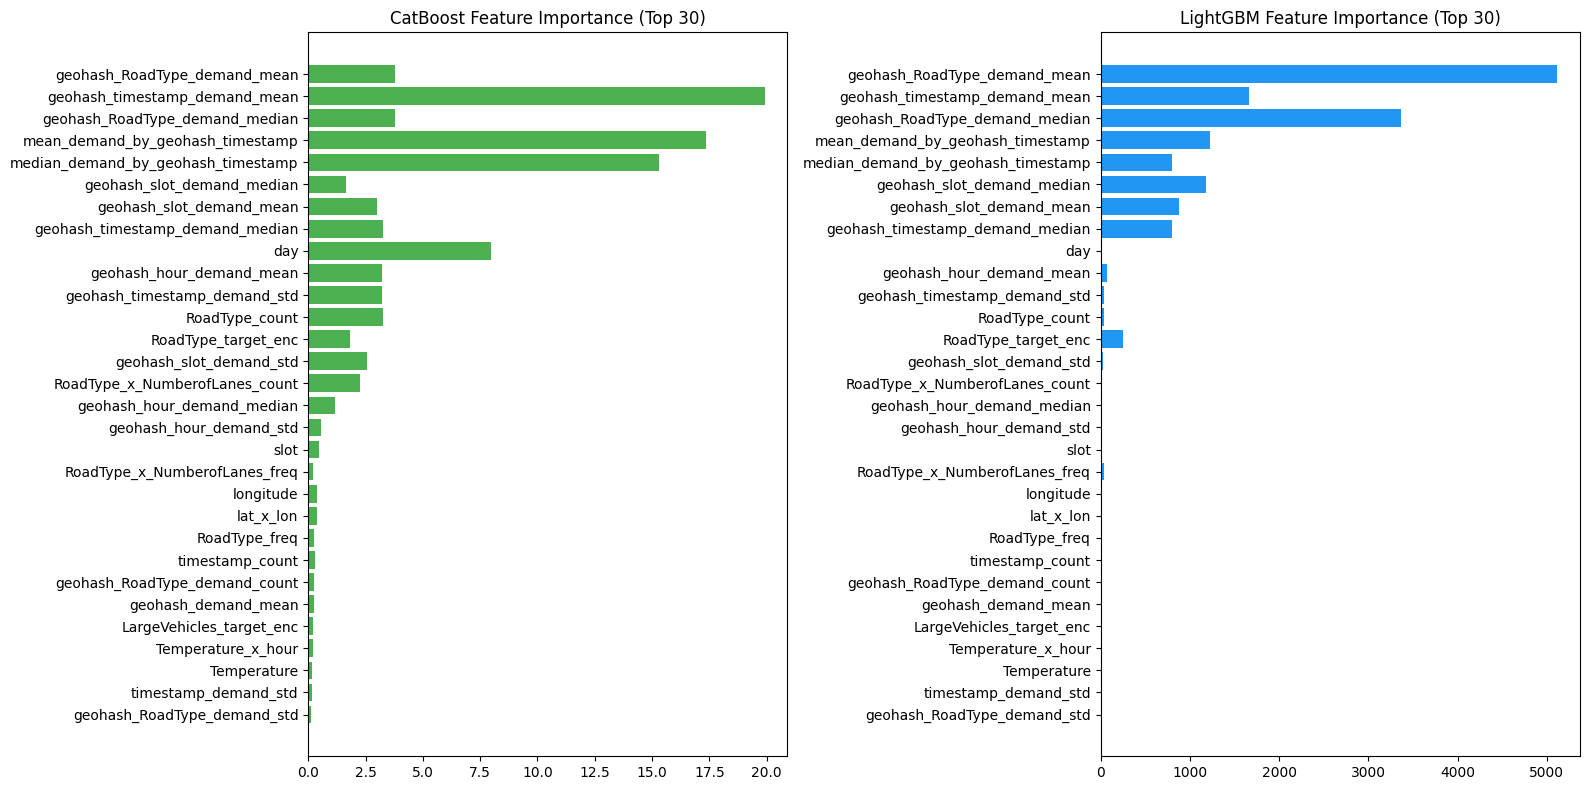


Top 15 Features:
                           feature  combined
      geohash_RoadType_demand_mean  0.183318
     geohash_timestamp_demand_mean  0.153044
    geohash_RoadType_demand_median  0.127160
  mean_demand_by_geohash_timestamp  0.126084
median_demand_by_geohash_timestamp  0.102279
        geohash_slot_demand_median  0.046351
          geohash_slot_demand_mean  0.043259
   geohash_timestamp_demand_median  0.041955
                               day  0.040361
          geohash_hour_demand_mean  0.018238
      geohash_timestamp_demand_std  0.017511
                    RoadType_count  0.017338
               RoadType_target_enc  0.017090
           geohash_slot_demand_std  0.013562
    RoadType_x_NumberofLanes_count  0.011500


In [20]:
importance_df = get_feature_importance(cb_models, lgb_models, feature_cols)
importance_df.to_csv(Config.OUTPUT_DIR / 'feature_importance.csv', index=False)
print('\nTop 15 Features:')
print(importance_df[['feature', 'combined']].head(15).to_string(index=False))

## 19. Submission Generation

In [21]:
submission_path = Config.SUB_DIR / Config.SUBMISSION_FILENAME
submission = generate_submission(
    final_preds, test, ID_COL, 'demand', submission_path
)

# Also save to root
submission.to_csv(Config.PROJECT_ROOT / 'submission.csv', index=False)
print(f'\nSubmission also saved to: {Config.PROJECT_ROOT / "submission.csv"}')

print('\n' + '=' * 70)
print('  Traffic Demand Prediction - COMPLETE')
print('=' * 70)
print(f'  CatBoost CV R2:  {np.mean(cb_scores):.6f}')
print(f'  LightGBM CV R2:  {np.mean(lgb_scores):.6f}')
print(f'  Ensemble R2:     {ensemble_r2:.6f}')
print(f'  Weights:         CB={best_weights[0]:.4f}, LGB={best_weights[1]:.4f}')
print(f'  Submission rows: {len(submission)}')
print('=' * 70)


  Submission saved: c:\Users\Shuvendu\Desktop\Flipkart_GridLock_2.0\Traffic_Demand_Prediction\outputs\submissions\submission.csv
  Shape: (41778, 2)
  Preview:
   Index    demand
0      0  0.028546
1      1  0.026335
2      2  0.026491
3      3  0.071454
4      4  0.107221

Submission also saved to: c:\Users\Shuvendu\Desktop\Flipkart_GridLock_2.0\Traffic_Demand_Prediction\submission.csv

  Traffic Demand Prediction - COMPLETE
  CatBoost CV R2:  0.995770
  LightGBM CV R2:  0.992941
  Ensemble R2:     0.996323
  Weights:         CB=0.7100, LGB=0.2900
  Submission rows: 41778
